# Example loading a batch of data using the PyTorch dataloader

In [ ]:
!pip install cartopy awscli skyfield
!pip install pandas==2.3.1

In [ ]:
# Download the data processing scripts
!git clone --filter=blob:none --sparse https://github.com/FrontierDevelopmentLab/2025-HL-Ionosphere-dataset.git 
!cd 2025-HL-Ionosphere-dataset && git sparse-checkout set scripts/
!sleep 2  # wait 2 seconds 
!mv 2025-HL-Ionosphere-dataset/scripts .
!rmdir 2025-HL-Ionosphere-dataset

### Imports

In [1]:
import os
import torch
import pickle
import hashlib
import tarfile
import datetime
import warnings
import numpy as np
import pandas as pd
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
import skyfield.api
from tqdm import tqdm
from glob import glob
from io import BytesIO
from functools import lru_cache
from torch.utils.data import Dataset

In [ ]:
from scripts.events.events import EventCatalog

from scripts.datasets.dataset_jpld import JPLD
from scripts.datasets.dataset_sequences import Sequences
from scripts.datasets.dataset_union import Union
from scripts.datasets.dataset_sunmoongeometry import SunMoonGeometry
from scripts.datasets.dataset_quasidipole import QuasiDipole
from scripts.datasets.dataset_celestrak import CelesTrak
from scripts.datasets.dataset_omniweb import OMNIWeb, omniweb_all_columns
from scripts.datasets.dataset_set import SET, set_all_columns
from scripts.datasets.dataloader_cached import CachedDataLoader

## Stream the dataset from AWS

In [ ]:
# Load Omniweb and JPLD data (only two JPLD files corresponding to end of the dataset)
!mkdir -p data/jpld
!mkdir -p data/omniweb/

!aws s3 sync --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/omniweb/ data/omniweb/

!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/tar_files_index_3a8334f288afd9deb25c6ec57c6b0cbb data/jpld/tar_files_index_3a8334f288afd9deb25c6ec57c6b0cbb
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-168.tar data/jpld/jpld-168.tar
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-169.tar data/jpld/jpld-169.tar
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-170.tar data/jpld/jpld-170.tar
!aws s3 cp --no-sign-request s3://nasa-radiant-data/helioai-datasets/ionosphere-data-public/jpld/webdataset/jpld-171.tar data/jpld/jpld-171.tar

## Load a single batch of data
Example of just loading a single batch of JPLD data and plotting it

In [3]:
# Create a dataset
dataset_jpld_dir = 'data/jpld'

date_start = datetime.datetime(2024, 5, 9)
date_end = datetime.datetime(2024, 5, 10)

dataset_jpld = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end)


JPLD
Directory      : data/jpld
Rewind minutes : 50
Loading tar files index from cache: data/jpld/tar_files_index_d814fb9516ff8e99467e7ba2e04a2f2a
Start date : 2024-05-09 00:00:00
End date   : 2024-05-10 00:00:00
Delta      : 15 minutes
Loading dates from cache: data/jpld/dates_index_2024-05-09T00:00:00_2024-05-10T00:00:00
TEC maps total    : 96
TEC maps available: 96
TEC maps dropped  : 0


In [4]:
# Load the JPLD map corresponding to date datetime.datetime(2024, 5, 9, 18, 30)
date = datetime.datetime(2024, 5, 9, 18, 30)
tec_map, tec_date = dataset_jpld[date]
print(tec_map.shape, tec_date)

torch.Size([1, 180, 360]) 2024-05-09T18:30:00


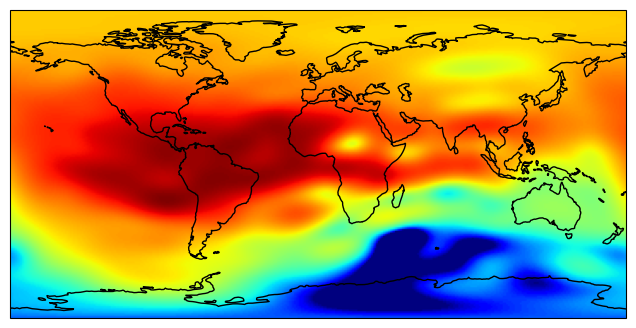

In [5]:
# Plot the TEC map
# Create a GeoAxes instance with a specific projection
fig = plt.figure(figsize=(8, 4))
ax = fig.add_subplot(1, 1, 1, projection=ccrs.PlateCarree())

im = ax.imshow(
    tec_map[0],
    extent=[-180, 180, -90, 90],
    origin='upper',
    cmap='jet',
    transform=ccrs.PlateCarree()
)

ax.coastlines()

plt.show()

## Sequence of multiple datasets setup
Example of setting up a sequence dataset for with the JPLD, OMNIWeb, and the SunMoon datasets

In [6]:
# Initialize variables
date_start = datetime.datetime(2024, 5, 9)
date_end = datetime.datetime(2024, 5, 10)
image_size = (180, 360)
context_window = 2 # Number of time steps of context used in model
prediction_window = 1 # Number of time steps to predict
training_sequence_length = context_window + prediction_window
delta_minutes = 15 # 15-minute cadence
date_dilation = 16 # Use 16x dilation for 15-min data to get 4-hour context

date_exclusions = []
datasets_omniweb_valid = []
datasets_jpld_valid = []
datasets_sunmoon_valid = []

dataset_omniweb_dir = 'data/omniweb/' #'/path/to/omniweb/data/'
dataset_jpld_dir = 'data/jpld' #'/path/to/jpld/data/'

# Create sequence dataset excluding validation events
dataset_jpld = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)
dataset_omniweb = OMNIWeb(dataset_omniweb_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions, return_as_image_size=image_size)
dataset_sunmoon = SunMoonGeometry(date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)

# Create Sequence datasets
dataset = Sequences(datasets=[dataset_jpld, dataset_omniweb, dataset_sunmoon], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)



JPLD
Directory      : data/jpld
Rewind minutes : 50
Loading tar files index from cache: data/jpld/tar_files_index_d814fb9516ff8e99467e7ba2e04a2f2a
Start date : 2024-05-09 00:00:00
End date   : 2024-05-10 00:00:00
Delta      : 15 minutes
Date exclusions:
Loading dates from cache: data/jpld/dates_index_2024-05-09T00:00:00_2024-05-10T00:00:00_4df58bd40b8a821dd5c2f09e3efd00eb
TEC maps total    : 96
TEC maps available: 96
TEC maps dropped  : 0

OMNIWeb
File indices           : data/omniweb/omniweb_indices_15min.csv
File magnetic field    : data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : data/omniweb/omniweb_solar_wind_15min.csv
Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omni

## Train and Validation setup

Example of setting up a dataset for training and validation using the JPLD, OMNIWeb, and the SunMoon datasets, excluding certain events for validation.

In [7]:
# Initialize variables
date_start = datetime.datetime(2024, 5, 9)
date_end = datetime.datetime(2024, 5, 10)
image_size = (180, 360)
context_window = 2 # Number of time steps of context used in model
prediction_window = 1 # Number of time steps to predict
training_sequence_length = context_window + prediction_window
delta_minutes = 15 # 15-minute cadence
date_dilation = 16 # Use 16x dilation for 15-min data to get 4-hour context

dataset_omniweb_dir = 'data/omniweb/' #'/path/to/omniweb/data/'
dataset_jpld_dir = 'data/jpld' #'/path/to/jpld/data/'

# Make a EventCatalog[event_id], a dict with keys:
# 'date_start': date_start,
# 'date_end': date_end,
# 'duration': duration,
# 'max_kp': max_kp,
# 'time_steps': time_steps
event_id = "G5H3-202405101500"
event_start = datetime.datetime(2024, 5, 10, 15, 0).isoformat()
event_end = datetime.datetime(2024, 5, 10, 18, 0).isoformat()
duration = datetime.datetime.fromisoformat(event_end) - datetime.datetime.fromisoformat(event_start)
max_kp = 9.0
time_steps = int(duration.total_seconds() / (15*60))
catalog = {}
catalog[event_id] = {
  'date_start': event_start,
  'date_end': event_end,
  'duration': duration,
  'max_kp': max_kp,
  'time_steps': time_steps
}

event_catalog = EventCatalog(catalog=catalog)
valid_event_id = ["G5H3-202405101500"]

date_exclusions = []
datasets_omniweb_valid = []
datasets_jpld_valid = []
datasets_sunmoon_valid = []

# Process validation events
for event_id in valid_event_id:
    print('Excluding event ID: {}'.format(event_id))

    if event_id not in event_catalog:
        raise ValueError('Event ID {} not found in EventCatalog'.format(event_id))

    event = event_catalog[event_id]
    exclusion_start = datetime.datetime.fromisoformat(event['date_start']) - datetime.timedelta(minutes=context_window * delta_minutes)
    exclusion_end = datetime.datetime.fromisoformat(event['date_end'])
    date_exclusions.append((exclusion_start, exclusion_end))
    print('Exclusion start: {}, end: {}'.format(exclusion_start, exclusion_end))

    datasets_omniweb_valid.append(OMNIWeb(dataset_omniweb_dir, date_start=exclusion_start, date_end=exclusion_end, return_as_image_size=image_size))
    datasets_jpld_valid.append(JPLD(dataset_jpld_dir, date_start=exclusion_start, date_end=exclusion_end))
    datasets_sunmoon_valid.append(SunMoonGeometry(date_start=exclusion_start, date_end=exclusion_end))

# Create validation dataset
dataset_jpld_valid = Union(datasets=datasets_jpld_valid)
dataset_omniweb_valid = Union(datasets=datasets_omniweb_valid)
dataset_sunmoon_valid = Union(datasets=datasets_sunmoon_valid)

# Create training dataset excluding validation events
dataset_jpld_train = JPLD(dataset_jpld_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)
dataset_omniweb_train = OMNIWeb(dataset_omniweb_dir, date_start=date_start, date_end=date_end, date_exclusions=date_exclusions, return_as_image_size=image_size)
dataset_sunmoon_train = SunMoonGeometry(date_start=date_start, date_end=date_end, date_exclusions=date_exclusions)

# Create Sequence datasets
dataset_valid = Sequences(datasets=[dataset_jpld_valid, dataset_omniweb_valid, dataset_sunmoon_valid], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)
dataset_train = Sequences(datasets=[dataset_jpld_train, dataset_omniweb_train, dataset_sunmoon_train], sequence_length=training_sequence_length, dilation=date_dilation, delta_minutes=delta_minutes)


Excluding event ID: G5H3-202405101500
Exclusion start: 2024-05-10 14:30:00, end: 2024-05-10 18:00:00

OMNIWeb
File indices           : data/omniweb/omniweb_indices_15min.csv
File magnetic field    : data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : data/omniweb/omniweb_solar_wind_15min.csv
Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns               : ['omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym

Filtering dates: 100%|██████████| 14/14 [00:00<00:00, 94557.58it/s]


Saving dates to cache: data/jpld/dates_index_2024-05-10T14:30:00_2024-05-10T18:00:00
TEC maps total    : 14
TEC maps available: 14
TEC maps dropped  : 0

Sun and Moon Geometry
Start date              : 2024-05-10 14:30:00
End date                : 2024-05-10 18:00:00
Delta                   : 15 minutes
Image size              : (180, 360)
Extra time steps        : 0

Union of datasets
Dataset : JPLD (2024-05-10 14:30:00 - 2024-05-10 18:00:00)

Union of datasets
Dataset : OMNIWeb (2024-05-10 14:30:00 - 2024-05-10 18:00:00)

Union of datasets
Dataset : SunMoonGeometry (2024-05-10 14:30:00 - 2024-05-10 18:00:00)

JPLD
Directory      : data/jpld
Rewind minutes : 50
Loading tar files index from cache: data/jpld/tar_files_index_d814fb9516ff8e99467e7ba2e04a2f2a
Start date : 2024-05-09 00:00:00
End date   : 2024-05-10 00:00:00
Delta      : 15 minutes
Date exclusions:
  2024-05-10 14:30:00 - 2024-05-10 18:00:00


Filtering dates: 100%|██████████| 96/96 [00:00<00:00, 398666.52it/s]

Saving dates to cache: data/jpld/dates_index_2024-05-09T00:00:00_2024-05-10T00:00:00_087c0d11480ed0af6f9f5c1806b7fe22
TEC maps total    : 96
TEC maps available: 96
TEC maps dropped  : 0

OMNIWeb
File indices           : data/omniweb/omniweb_indices_15min.csv
File magnetic field    : data/omniweb/omniweb_magnetic_field_15min.csv
File solar wind        : data/omniweb/omniweb_solar_wind_15min.csv


Data shape             : (498625, 15)
Data columns           : ['all__dates_datetime__', 'omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'source__gaps_flag__', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Delta minutes         : 15
Normalize             : True
Rewind minutes        : 50
Columns               : ['omniweb__ae_index__[nT]', 'omniweb__al_index__[nT]', 'omniweb__au_index__[nT]', 'omniweb__sym_d__[nT]', 'omniweb__sym_h__[nT]', 'omniweb__asy_d__[nT]', 'omniweb__bx_gse__[nT]', 'omniweb__by_gse__[nT]', 'omniweb__bz_gse__[nT]', 'omniweb__speed__[km/s]', 'omniweb__vx_velocity__[km/s]', 'omniweb__vy_velocity__[km/s]', 'omniweb__vz_velocity__[km/s]']
Return as image size  : (180, 360)
Rows before processing: 498,625
Date exclusio